## 스테이블 디퓨전 모델 스크래치 코드

하이퍼파라메터 정의

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# 하이퍼파라미터 설정
IMG_SIZE = 64  
BATCH_SIZE = 64  # VRAM 8GB 활용을 위해 배치 크기 조정
LEARNING_RATE = 2e-4  
EPOCHS = 5  
TIMESTEPS = 1000  
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


Using device: cuda


데이터셋 준비

In [ ]:
class MNISTTextDataset(Dataset):
	"""MNIST 이미지와 해당 숫자에 대한 텍스트 설명을 쌍으로 반환하는 데이터셋"""
	def __init__(self, mnist_dataset):
		self.mnist_dataset = mnist_dataset
		self.text_labels = [f"A digit {i}" for i in range(10)]

	def __len__(self):
		return len(self.mnist_dataset)

	def __getitem__(self, idx):
		image, label = self.mnist_dataset[idx]
		text = self.text_labels[label]
		# 텍스트를 나중에 임베딩하기 위해 레이블 인덱스를 그대로 사용
		return image, label

# MNIST 데이터셋 로드 및 변환
transform = transforms.Compose([
	transforms.Resize((IMG_SIZE, IMG_SIZE)),
	transforms.ToTensor(),
	transforms.Normalize((0.5,), (0.5,)) # -1 ~ 1 범위로 정규화
])
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 데이터셋을 80:20으로 분할
train_size = int(0.8 * len(mnist_train))
val_size = len(mnist_train) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(mnist_train, [train_size, val_size])
print(f"Train dataset size: {train_size}, Validation dataset size: {val_size}")

# 커스텀 데이터셋 적용
train_custom_dataset = MNISTTextDataset(train_dataset)
val_custom_dataset = MNISTTextDataset(val_dataset)

# 데이터로더 생성
train_dataloader = DataLoader(train_custom_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_custom_dataset, batch_size=BATCH_SIZE, shuffle=False)



Train dataset size: 48000, Validation dataset size: 12000


<div style="font-size: 90%;">
확산 모델: 노이즈 스케줄 및 파라미터 정의 (Forward Process)

시간 스텝 t에 따른 노이즈 분산 $beta_t$와, 이를 바탕으로 원본 이미지 $\mathbf{x}_0$에 노이즈를 한 번에 더하기 위한 누적 파라미터들을 계산.

$$
\begin{aligned}
\beta_t &= \text{linspace}(10^{-4}, 0.02, T) && \text{(betas)} \\[6pt]
\alpha_t &= 1 - \beta_t && \text{(alphas)} \\[6pt]
\bar{\alpha}_t &= \prod_{i=1}^{t} \alpha_i && \text{(alphas\_cumprod)} \\[6pt]
\bar{\alpha}_{t-1} &= \text{Previous } \bar{\alpha}_t \; (\bar{\alpha}_0 = 1) && \text{(alphas\_cumprod\_prev)} \\[6pt]
\end{aligned}
$$

최종 노이즈 주입용 파라미터:
$$ \sqrt{\bar{\alpha}_t}, \quad \sqrt{1 - \bar{\alpha}_t} $$

</div>

In [ ]:
def linear_beta_schedule(timesteps):
	"""선형 스케줄에 따라 beta 값들을 생성"""
	beta_start = 0.0001
	beta_end = 0.02
	return torch.linspace(beta_start, beta_end, timesteps)

betas = linear_beta_schedule(TIMESTEPS).to(DEVICE)

alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=DEVICE), alphas_cumprod[:-1]])
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

<div style="font-size: 90%;">

확산 모델: 전방향 프로세스 (Forward Process / q_sample)

원본 이미지 $\mathbf{x}_0$에 시간 스텝 $t$에 해당하는 가우시안 노이즈를 한 번에 주입하여, 노이즈가 낀 이미지 $\mathbf{x}_t$를 생성하는 수식.

$$ \mathbf{x}_t = \sqrt{\bar{\alpha}_t} \mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t} \boldsymbol{\epsilon} $$

* $\mathbf{x}_0$: 원본 이미지 (`x_start`)
* $\mathbf{x}_t$: $t$ 시점의 생성된 노이즈 이미지
* $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$: 무작위 가우시안 노이즈 (`noise`)
* $\sqrt{\bar{\alpha}_t}$: 원본 이미지가 보존되는 비율 (`sqrt_alphas_cumprod_t`)
* $\sqrt{1 - \bar{\alpha}_t}$: 노이즈가 섞이는 비율 (`sqrt_one_minus_alphas_cumprod_t`)

</div>

In [ ]:
def q_sample(x_start, t, noise=None):
	"""Forward Process: 원본 이미지 x_start에 t 시점만큼의 노이즈를 추가"""
	if noise is None:
		noise = torch.randn_like(x_start)
	
	sqrt_alphas_cumprod_t = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
	sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
	
	return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise


모델 구조 정의

<div style="font-size: 90%;">

시간 정보 벡터화: 정현파 위치 임베딩 (Sinusoidal Position Embeddings)

단순한 숫자(스칼라)인 시간 스텝 $t$를 신경망이 이해하기 쉬운 고차원 벡터로 변환하기 위해, 서로 다른 주파수를 가진 사인(Sine)과 코사인(Cosine) 함수를 교차하여 결합.

$$ PE_{(t, 2i)} = \sin\left( \frac{t}{10000^{2i/d}} \right) $$
$$ PE_{(t, 2i+1)} = \cos\left( \frac{t}{10000^{2i/d}} \right) $$

* $t$: 현재 시간 스텝 (`time`)
* $d$: 임베딩 벡터의 총 차원 수 (`dim`)
* $i$: 차원의 인덱스 ($0 \le i < d/2$)

</div>

In [ ]:
class SinusoidalPositionEmbeddings(nn.Module):
	"""시간(timestep) 정보를 벡터로 변환하는 포지셔널 임베딩"""
	def __init__(self, dim):
		super().__init__()
		self.dim = dim

	def forward(self, time):
		half_dim = self.dim // 2
		embeddings = np.log(10000) / (half_dim - 1)
		embeddings = torch.exp(torch.arange(half_dim, device=DEVICE) * -embeddings)
		embeddings = time[:, None] * embeddings[None, :]
		embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
		return embeddings

class ResNetBlock(nn.Module):
	"""ResNet 스타일의 잔차 연결이 있는 블록"""
	def __init__(self, in_ch, out_ch, time_emb_dim, dropout=0.1):
		super().__init__()
		self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
		self.norm1 = nn.GroupNorm(min(8, out_ch//4), out_ch)
		self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
		self.norm2 = nn.GroupNorm(min(8, out_ch//4), out_ch)
		self.time_mlp = nn.Sequential(
			nn.SiLU(),
			nn.Linear(time_emb_dim, out_ch)
		)
		self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
		self.dropout = nn.Dropout(dropout)
		self.silu = nn.SiLU()

	def forward(self, x, t):
		h = self.conv1(x)
		h = self.norm1(h)
		h = self.silu(h)
		
		# 시간 임베딩 추가
		time_emb = self.time_mlp(t)
		h = h + time_emb.unsqueeze(-1).unsqueeze(-1)
		
		h = self.dropout(h)
		h = self.conv2(h)
		h = self.norm2(h)
		
		return self.silu(h + self.shortcut(x))


<div style="font-size: 90%;">

스케일 내적 어텐션 (Scaled Dot-Product Attention)

이미지 내의 어떤 픽셀이 다른 어떤 픽셀과 연관이 깊은지(Attention)를 계산하여, 전역적인 문맥(Global Context)을 파악하는 수식.

$$ \text{Attention}(Q, K, V) = \text{softmax}\left( \frac{Q K^T}{\sqrt{d_k}} \right) V $$

* $Q, K, V$: 쿼리(Query), 키(Key), 값(Value) 행렬. (이미지의 공간 차원 $H \times W$를 1차원 시퀀스로 펴서 사용)
* $d_k$: 채널의 차원 수 (`c`). 벡터 내적 값이 너무 커져서 Softmax 기울기가 소실되는 것을 막기 위해 $\frac{1}{\sqrt{c}}$ (`scale`)로 나누어 줌.
* $Q K^T$: 코드의 `q @ k` 부분으로, 모든 픽셀 쌍 간의 유사도 점수(Attention Score)를 계산.

</div>

In [ ]:
class AttentionBlock(nn.Module):
	"""Self-Attention 블록"""
	def __init__(self, channels):
		super().__init__()
		self.channels = channels
		self.norm = nn.GroupNorm(min(8, channels//4), channels)
		self.qkv = nn.Conv2d(channels, channels * 3, 1)
		self.proj_out = nn.Conv2d(channels, channels, 1)

	def forward(self, x):
		b, c, h, w = x.shape
		x_norm = self.norm(x)
		qkv = self.qkv(x_norm)
		q, k, v = qkv.chunk(3, dim=1)
		
		q = q.view(b, c, h * w).transpose(-1, -2) # Reshape for attention
		k = k.view(b, c, h * w)
		v = v.view(b, c, h * w).transpose(-1, -2)
		
		# Attention
		scale = (c ** (-0.5))
		attn = torch.softmax(q @ k * scale, dim=-1)
		out = (attn @ v).transpose(-1, -2).view(b, c, h, w)
		
		return x + self.proj_out(out)


U-Net

In [ ]:
class ImprovedUNet(nn.Module):
	""" U-Net 모델 - 8GB VRAM 활용"""
	def __init__(self, in_channels=1, out_channels=1, time_emb_dim=128, text_emb_dim=256):
		super().__init__()
		
		# 텍스트 레이블 임베딩 (더 큰 차원)
		self.text_embedding = nn.Embedding(num_embeddings=10, embedding_dim=text_emb_dim)

		# 시간 임베딩 (더 큰 차원)
		self.time_mlp = nn.Sequential(
			SinusoidalPositionEmbeddings(time_emb_dim),
			nn.Linear(time_emb_dim, time_emb_dim * 2),
			nn.SiLU(),
			nn.Linear(time_emb_dim * 2, time_emb_dim),
		)

		# 초기 projection
		self.init_conv = nn.Conv2d(in_channels, 64, 3, padding=1)

		# Down-sampling path (더 깊은 구조)
		self.down1 = nn.ModuleList([
			ResNetBlock(64, 64, time_emb_dim),
			ResNetBlock(64, 64, time_emb_dim)
		])
		self.down2 = nn.ModuleList([
			ResNetBlock(64, 128, time_emb_dim),
			ResNetBlock(128, 128, time_emb_dim),
			AttentionBlock(128)
		])
		self.down3 = nn.ModuleList([
			ResNetBlock(128, 256, time_emb_dim),
			ResNetBlock(256, 256, time_emb_dim),
			AttentionBlock(256)
		])
		self.down4 = nn.ModuleList([
			ResNetBlock(256, 512, time_emb_dim),
			ResNetBlock(512, 512, time_emb_dim)
		])

		# Middle blocks with text injection
		self.mid_block1 = ResNetBlock(512 + text_emb_dim, 512, time_emb_dim)
		self.mid_attn = AttentionBlock(512)
		self.mid_block2 = ResNetBlock(512, 512, time_emb_dim)

		# Up-sampling path
		self.up1 = nn.ModuleList([
			ResNetBlock(512 + 512, 512, time_emb_dim),
			ResNetBlock(512, 512, time_emb_dim),
			ResNetBlock(512, 256, time_emb_dim)
		])
		self.up2 = nn.ModuleList([
			ResNetBlock(256 + 256, 256, time_emb_dim),
			ResNetBlock(256, 256, time_emb_dim),
			ResNetBlock(256, 128, time_emb_dim),
			AttentionBlock(128)
		])
		self.up3 = nn.ModuleList([
			ResNetBlock(128 + 128, 128, time_emb_dim),
			ResNetBlock(128, 128, time_emb_dim),
			ResNetBlock(128, 64, time_emb_dim),
			AttentionBlock(64)
		])
		self.up4 = nn.ModuleList([
			ResNetBlock(64 + 64, 64, time_emb_dim),
			ResNetBlock(64, 64, time_emb_dim)
		])

		# Down/Up sampling operations
		self.downsample = nn.MaxPool2d(2)
		self.upsample1 = nn.ConvTranspose2d(512, 512, 2, 2)
		self.upsample2 = nn.ConvTranspose2d(256, 256, 2, 2)
		self.upsample3 = nn.ConvTranspose2d(128, 128, 2, 2)
		self.upsample4 = nn.ConvTranspose2d(64, 64, 2, 2)

		# 최종 출력 레이어
		self.final_conv = nn.Sequential(
			nn.GroupNorm(8, 64),
			nn.SiLU(),
			nn.Conv2d(64, out_channels, 3, padding=1)
		)

	def forward(self, x, t, text_labels):
		# 시간 임베딩
		t_emb = self.time_mlp(t)
		
		# 초기 projection
		x = self.init_conv(x)
		
		# Down-sampling with skip connections
		skip_connections = []
		
		# Down 1 (64x64 -> 32x32)
		for layer in self.down1:
			x = layer(x, t_emb)
		skip_connections.append(x)
		x = self.downsample(x)
		
		# Down 2 (32x32 -> 16x16)
		for layer in self.down2:
			if isinstance(layer, AttentionBlock):
				x = layer(x)
			else:
				x = layer(x, t_emb)
		skip_connections.append(x)
		x = self.downsample(x)
		
		# Down 3 (16x16 -> 8x8)
		for layer in self.down3:
			if isinstance(layer, AttentionBlock):
				x = layer(x)
			else:
				x = layer(x, t_emb)
		skip_connections.append(x)
		x = self.downsample(x)
		
		# Down 4 (8x8 -> 4x4)
		for layer in self.down4:
			x = layer(x, t_emb)
		skip_connections.append(x)
		x = self.downsample(x)
		
		# Middle with text injection (2x2)
		text_emb = self.text_embedding(text_labels)
		text_emb_expanded = text_emb.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, x.shape[2], x.shape[3])
		x = torch.cat([x, text_emb_expanded], dim=1)
		
		x = self.mid_block1(x, t_emb)
		x = self.mid_attn(x)
		x = self.mid_block2(x, t_emb)
		
		# Up-sampling with skip connections
		# Up 1 (2x2 -> 4x4)
		x = self.upsample1(x)
		x = torch.cat([x, skip_connections.pop()], dim=1)
		for layer in self.up1:
			x = layer(x, t_emb)
		
		# Up 2 (4x4 -> 8x8)
		x = self.upsample2(x)
		x = torch.cat([x, skip_connections.pop()], dim=1)
		for layer in self.up2:
			if isinstance(layer, AttentionBlock):
				x = layer(x)
			else:
				x = layer(x, t_emb)
		
		# Up 3 (8x8 -> 16x16)
		x = self.upsample3(x)
		x = torch.cat([x, skip_connections.pop()], dim=1)
		for layer in self.up3:
			if isinstance(layer, AttentionBlock):
				x = layer(x)
			else:
				x = layer(x, t_emb)
		
		# Up 4 (16x16 -> 32x32)
		x = self.upsample4(x)
		x = torch.cat([x, skip_connections.pop()], dim=1)
		for layer in self.up4:
			x = layer(x, t_emb)
		
		return self.final_conv(x)


학습 검증 함수 정의

In [5]:
@torch.no_grad()
def validate_model(model, val_dataloader, criterion):
	"""검증 데이터셋에서 모델 성능 평가"""
	model.eval()
	val_loss = 0.0
	num_batches = 0
	
	for images, labels in val_dataloader:
		images = images.to(DEVICE)
		labels = labels.to(DEVICE)
		
		# 랜덤 타임스텝 t 샘플링
		t = torch.randint(0, TIMESTEPS, (images.shape[0],), device=DEVICE).long()
		
		# 노이즈 생성 및 노이즈가 추가된 이미지 생성
		noise = torch.randn_like(images)
		x_t = q_sample(x_start=images, t=t, noise=noise)
		
		# 모델을 통해 노이즈 예측
		predicted_noise = model(x_t, t, labels)
		
		# 손실 계산
		loss = criterion(noise, predicted_noise)
		val_loss += loss.item()
		num_batches += 1
	
	model.train()
	return val_loss / num_batches

모델 학습

In [6]:
model = ImprovedUNet(text_emb_dim=256).to(DEVICE)  # 개선된 모델 사용
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)  # AdamW 사용
criterion = nn.MSELoss()

# 학습률 스케줄러 추가
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# 모델 파라미터 수 출력
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("Training started...")

# Best 모델 저장을 위한 변수 초기화
best_val_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
	model.train()
	epoch_loss = 0
	loop = tqdm(train_dataloader, leave=True)
	for batch_idx, (images, labels) in enumerate(loop):
		images = images.to(DEVICE)
		labels = labels.to(DEVICE)
		
		# 1. 랜덤 타임스텝 t 샘플링
		t = torch.randint(0, TIMESTEPS, (images.shape[0],), device=DEVICE).long()
		
		# 2. 노이즈 생성 및 노이즈가 추가된 이미지 생성 (Forward)
		noise = torch.randn_like(images)
		x_t = q_sample(x_start=images, t=t, noise=noise)
		
		# 3. 모델을 통해 노이즈 예측
		predicted_noise = model(x_t, t, labels)
		
		# 4. 손실 계산 및 파라미터 업데이트
		loss = criterion(noise, predicted_noise)
		
		optimizer.zero_grad()
		loss.backward()
		
		# Gradient clipping for stability
		torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
		
		optimizer.step()
		
		epoch_loss += loss.item()
		loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
		loop.set_postfix(loss=loss.item(), lr=optimizer.param_groups[0]['lr'])
	
	# 검증 손실 계산
	val_loss = validate_model(model, val_dataloader, criterion)
	
	# 학습률 스케줄러 업데이트
	scheduler.step()
	
	# 에포크별 평균 loss 출력
	avg_train_loss = epoch_loss / len(train_dataloader)
	train_losses.append(avg_train_loss)
	val_losses.append(val_loss)
	
	print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")
	
	# Best 모델 저장
	if val_loss < best_val_loss:
		best_val_loss = val_loss
		torch.save(model.state_dict(), 'best_diffusion_mnist_model.pth')
		print(f"New best model saved! Val Loss: {val_loss:.6f}")
	
	# 주기적으로 모델 저장
	if (epoch + 1) % 10 == 0:
		torch.save(model.state_dict(), f'improved_diffusion_mnist_epoch_{epoch+1}.pth')
		print(f"Model saved at epoch {epoch+1}")

print("Training finished.")

Total parameters: 44,673,601
Trainable parameters: 44,673,601
Training started...


Epoch [1/5]: 100%|██████████| 750/750 [17:51<00:00,  1.43s/it, loss=0.0189, lr=0.0002] 


Epoch [1/5] - Train Loss: 0.030741, Val Loss: 0.010206
New best model saved! Val Loss: 0.010206


Epoch [2/5]: 100%|██████████| 750/750 [22:24<00:00,  1.79s/it, loss=0.0137, lr=0.000181] 


Epoch [2/5] - Train Loss: 0.011045, Val Loss: 0.007849
New best model saved! Val Loss: 0.007849


...

Epoch [3/5] - Train Loss: 0.008653, Val Loss: 0.007003
New best model saved! Val Loss: 0.007003


Epoch [4/5]: 100%|██████████| 750/750 [22:15<00:00,  1.78s/it, loss=0.0106, lr=6.91e-5] 


Epoch [4/5] - Train Loss: 0.007676, Val Loss: 0.006335
New best model saved! Val Loss: 0.006335


Epoch [5/5]: 100%|██████████| 750/750 [22:38<00:00,  1.81s/it, loss=0.00724, lr=1.91e-5]


Epoch [5/5] - Train Loss: 0.007391, Val Loss: 0.006193
New best model saved! Val Loss: 0.006193
Training finished.


학습 결과 확인

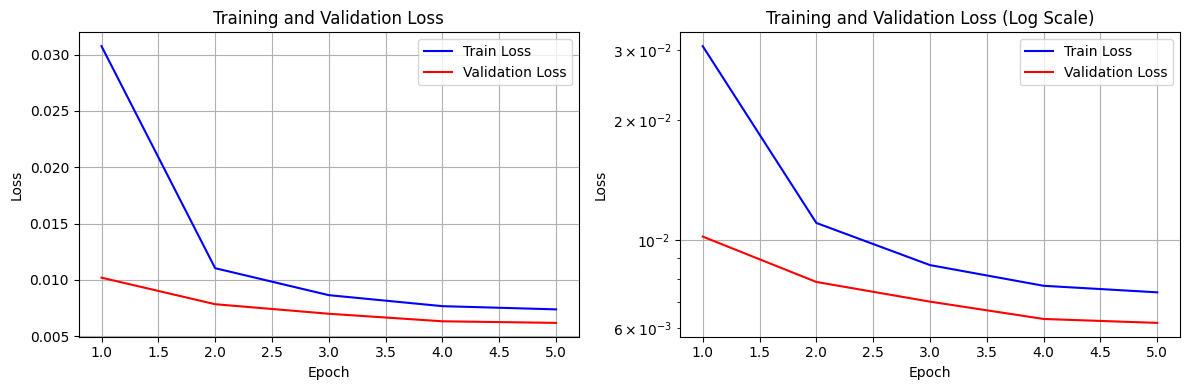

Best validation loss: 0.006193
Training curves saved as 'training_curves.png'
Best model saved as 'best_diffusion_mnist_model.pth'


In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Best validation loss: {best_val_loss:.6f}")
print("Training curves saved as 'training_curves.png'")
print("Best model saved as 'best_diffusion_mnist_model.pth'")

텍스트 to 이미지 생성 함수 정의 및 테스트

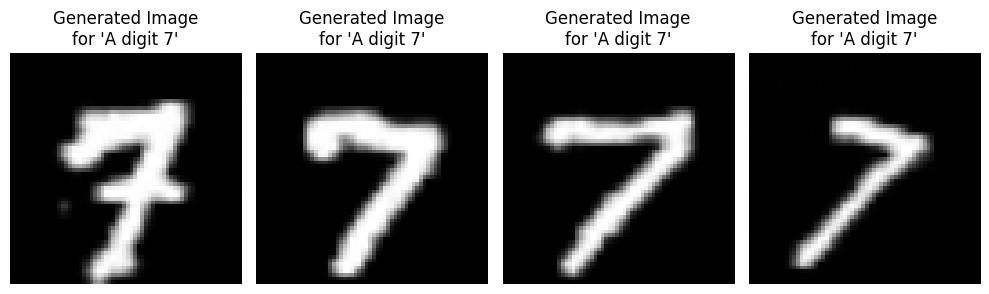

''

In [ ]:
@torch.no_grad()
def generate_image(model, text_label_index, num_images=1):
	"""학습된 모델을 사용하여 텍스트로부터 이미지를 생성"""
	model.eval()
	
	shape = (num_images, 1, IMG_SIZE, IMG_SIZE)
	img = torch.randn(shape, device=DEVICE)
	text_labels = torch.tensor([text_label_index] * num_images, device=DEVICE)

	for i in tqdm(reversed(range(0, TIMESTEPS)), desc='Sampling', total=TIMESTEPS, leave=False):
		t = torch.full((num_images,), i, device=DEVICE, dtype=torch.long)
		predicted_noise = model(img, t, text_labels)

		# 노이즈 제거 (DDPM 샘플링 공식)
		alpha_t = alphas[t].view(-1, 1, 1, 1)
		alpha_t_cumprod = alphas_cumprod[t].view(-1, 1, 1, 1)
		sqrt_one_minus_alpha_t_cumprod = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
		
		model_mean = (1.0 / torch.sqrt(alpha_t)) * (img - (1.0 - alpha_t) / sqrt_one_minus_alpha_t_cumprod * predicted_noise)
		
		if i == 0:
			img = model_mean
		else:
			noise = torch.randn_like(img)
			posterior_variance = betas[t].view(-1, 1, 1, 1)
			img = model_mean + torch.sqrt(posterior_variance) * noise
			
	model.train()
	# 이미지를 0~1 범위로 되돌리기
	img = (img.clamp(-1, 1) + 1) / 2
	return img.cpu()

# 생성 테스트
# 생성하고 싶은 숫자를 0부터 9 사이의 정수로 지정
target_digit = 7 
generated_images = generate_image(model, text_label_index=target_digit, num_images=4)

# 결과 시각화
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i, img_tensor in enumerate(generated_images):
	axes[i].imshow(img_tensor.squeeze(), cmap='gray')
	axes[i].set_title(f"Generated Image\nfor 'A digit {target_digit}'")
	axes[i].axis('off')
plt.tight_layout()
plt.show()

# 모델 저장
torch.save(model.state_dict(), 'stable_diffusion_mnist.pth')
